In [3]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor # REPLACED XGBOOST
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance # ADDED FOR VISUALIZATION

# Set local visual style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({'font.size': 10})

In [8]:
# ==========================================
# 1. Data Generation
# ==========================================
np.random.seed(42)
num_records = 5000
makes_models = {
    'Skoda': ['Kylaq', 'Slavia', 'Kushaq'], 
    'Mahindra': ['3XO', 'XUV700', 'Thar'], 
    'Kia': ['Sonet', 'Seltos', 'Carens']
}
severities = ['01-minor', '02-moderate', '03-severe']
years = np.random.randint(2018, 2025, size=num_records)

# Using a standard loop to avoid syntax/linter errors
data = []
for i in range(num_records):
    make = np.random.choice(list(makes_models.keys()))
    model = np.random.choice(makes_models[make])
    severity = np.random.choice(severities, p=[0.5, 0.3, 0.2])
    year = years[i]
    
    data.append({
        'auto_make': make, 
        'auto_model': model, 
        'auto_year': year, 
        'incident_severity': severity
    })

df = pd.DataFrame(data)

def calculate_claim(row):
    if row['incident_severity'] == '01-minor':
        base_cost = np.random.normal(500, 100)
    elif row['incident_severity'] == '02-moderate':
        base_cost = np.random.normal(2500, 500)
    else:
        base_cost = np.random.normal(8000, 1500)
        
    return max(200, round(base_cost + ((row['auto_year'] - 2018) * 120), 2))

df['vehicle_claim'] = df.apply(calculate_claim, axis=1)

/var/folders/b7/c8tn8fx960ndptt_z_rsl1200000gp/T/ipykernel_41435/3853824903.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='incident_severity', y='vehicle_claim', data=df, order=severities, palette='magma', ax=axes[1])


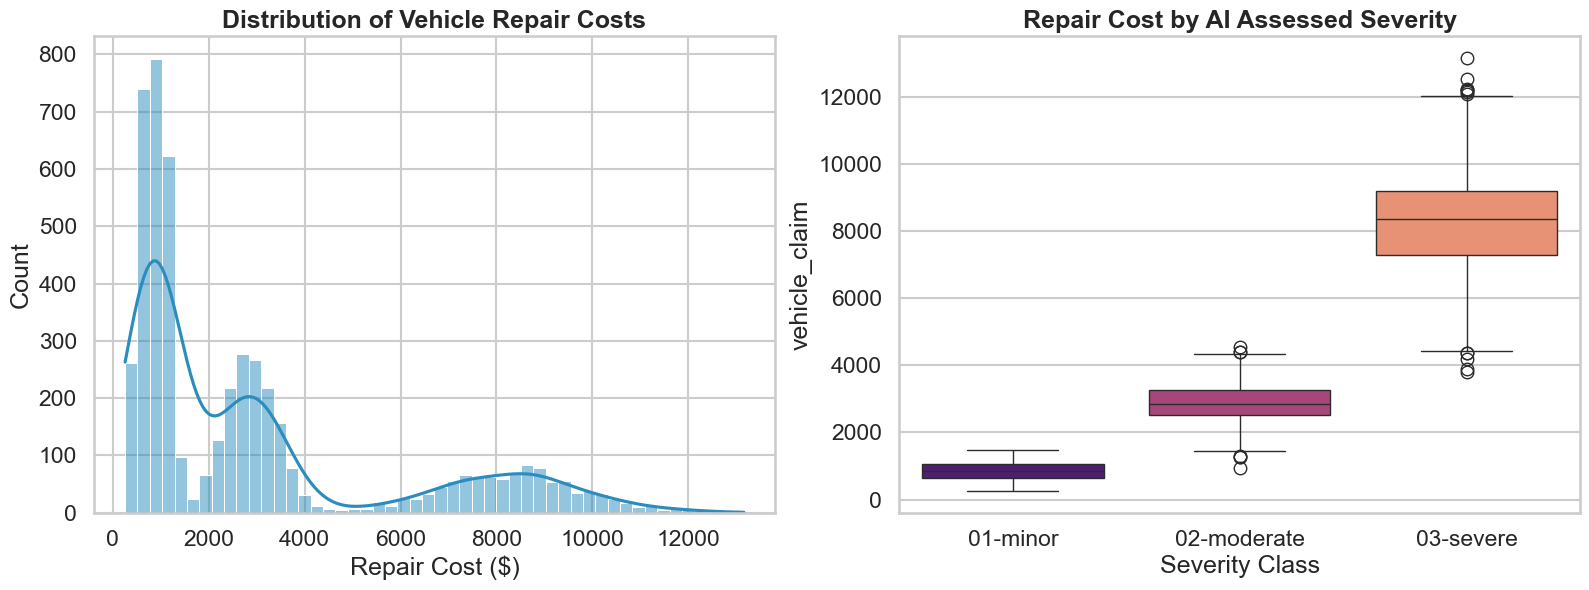

In [9]:
# ==========================================
# 2. EDA VISUALIZATIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Dist Plot
sns.histplot(df['vehicle_claim'], bins=50, kde=True, color='#2b8cbe', ax=axes[0])
axes[0].set_title('Distribution of Vehicle Repair Costs', fontweight='bold')
axes[0].set_xlabel('Repair Cost ($)')
# Box Plot
sns.boxplot(x='incident_severity', y='vehicle_claim', data=df, order=severities, palette='magma', ax=axes[1])
axes[1].set_title('Repair Cost by AI Assessed Severity', fontweight='bold')
axes[1].set_xlabel('Severity Class')
plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# 3. Model Training (Using HistGradientBoosting)
# ==========================================
X = df.drop('vehicle_claim', axis=1)
y = df['vehicle_claim']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = ['auto_make', 'auto_model', 'incident_severity']
numeric_features = ['auto_year']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # max_iter is the equivalent of n_estimators in XGBoost
    ('regressor', HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=5, random_state=42))
])

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)
print(f"Model Trained! RMSE: ${np.sqrt(mean_squared_error(y_test, preds)):.2f} | R2: {r2_score(y_test, preds):.3f}")

Model Trained! RMSE: $741.66 | R2: 0.939


Calculating feature importance...


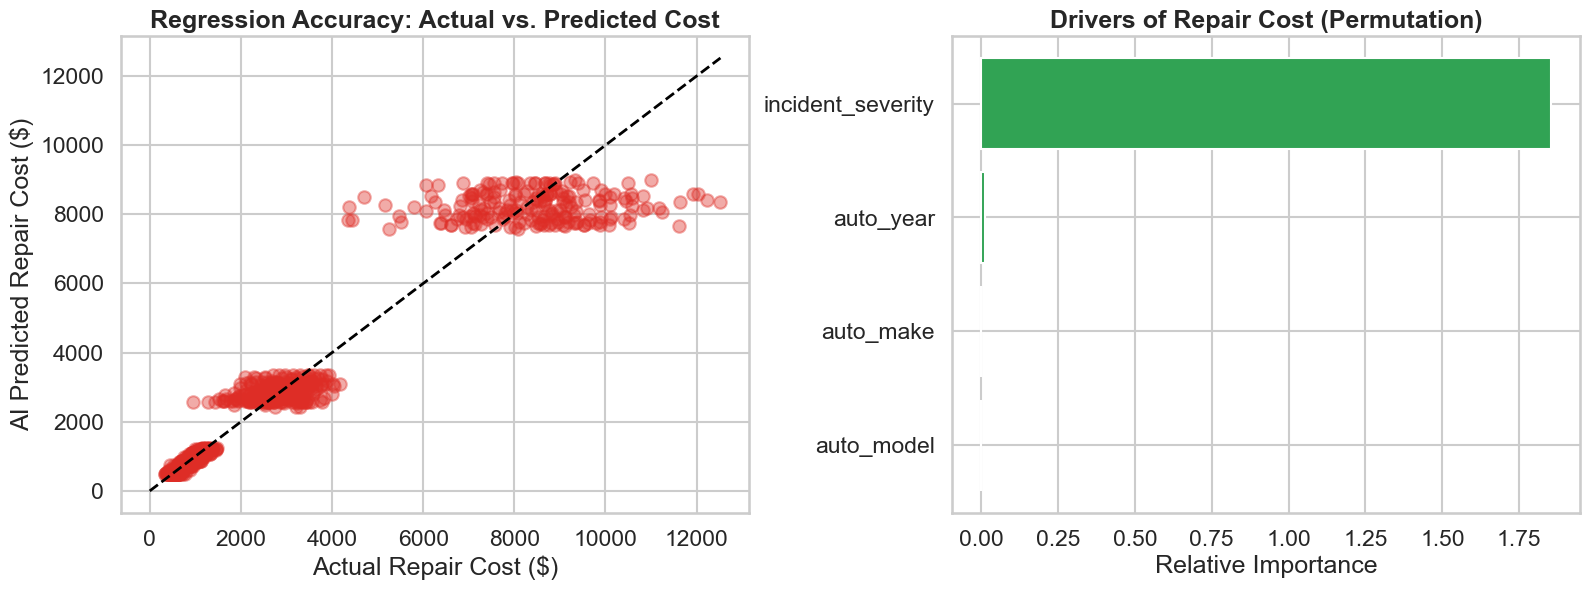

Pipeline saved to 'saved_models/pricing_sklearn_pipeline.pkl'


In [12]:
# ==========================================
# 4. EVALUATION VISUALIZATIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
axes[0].scatter(y_test, preds, alpha=0.4, color='#de2d26')
max_val = max(max(y_test), max(preds))
axes[0].plot([0, max_val], [0, max_val], color='black', linestyle='--', lw=2)
axes[0].set_title('Regression Accuracy: Actual vs. Predicted Cost', fontweight='bold')
axes[0].set_xlabel('Actual Repair Cost ($)')
axes[0].set_ylabel('AI Predicted Repair Cost ($)')

# Feature Importance (Using Permutation Importance)
print("Calculating feature importance...")

# THE FIX: Use the original column names because permutation importance 
# evaluates the pipeline inputs, not the preprocessor outputs!
feature_names = X_test.columns.tolist() 
r = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42)

# Create DataFrame and sort
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': r.importances_mean}).sort_values(by='Importance', ascending=True)

# Plot
axes[1].barh(feat_df['Feature'], feat_df['Importance'], color='#31a354')
axes[1].set_title('Drivers of Repair Cost (Permutation)', fontweight='bold')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

# Save
joblib.dump(pipeline, 'saved_models/pricing_sklearn_pipeline.pkl')
print("Pipeline saved to 'saved_models/pricing_sklearn_pipeline.pkl'")